<a href="https://colab.research.google.com/github/yashita-mishra/IML-Assignment/blob/main/A2Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from datasets import load_dataset
import torch as nn

mnist_dataset = load_dataset("fashion_mnist")
mnist_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [12]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import torch
import numpy as np
class FashionMNISTDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        image = self.hf_dataset[idx]['image']
        label = self.hf_dataset[idx]['label']

        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.flatten())
])

train_dataset = FashionMNISTDataset(mnist_dataset['train'], transform=transform)
test_dataset = FashionMNISTDataset(mnist_dataset['test'], transform=transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

for images, labels in train_loader:
    print(f"Shape of image batch: {images.shape}")
    print(f"Shape of label batch: {labels.shape}")
    break

Number of training batches: 1875
Number of test batches: 313
Shape of image batch: torch.Size([32, 784])
Shape of label batch: torch.Size([32])


In [13]:
import torch.nn as nn

class Autoencode(nn.Module):
  def __init__(self, hidden_dims, input_dim=784):
    super().__init__()
    dims = [input_dim] + list(hidden_dims)
    enclayers = []
    for i in range(len(dims) - 1):
      enclayers.append(nn.Linear(dims[i], dims[i+1]))
      if i < len(dims) - 2:
        enclayers.append(nn.ReLU(inplace=True))
    self.encoder = nn.Sequential(*enclayers)

    rev = list(reversed(dims))
    declayers = []
    for i in range(len(rev) - 1):
      declayers.append(nn.Linear(rev[i], rev[i+1]))
      if i < len(rev) - 2:
        declayers.append(nn.ReLU(inplace=True))
    declayers.append(nn.Sigmoid())
    self.decoder = nn.Sequential(*declayers)

  def forward(self, x):
    z = self.encoder(x)
    x_hat = self.decoder(z)
    return x_hat, z

In [14]:
import torch.optim as optim
hidden_dims = [256, 128, 64]
input_dim = 784
learning_rate = 1e-3
num_epochs = 10
model = Autoencode(hidden_dims=hidden_dims, input_dim=input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(model)
print(f"Loss Function: {criterion}")
print(f"Optimizer: {optimizer}")

Autoencode(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)
Loss Function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Using device: {device}")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        reconstructed_data, _ = model(data)
        loss = criterion(reconstructed_data, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {avg_train_loss:.4f}')

print("Training complete!")

Using device: cpu
Epoch [1/10], Training Loss: 0.0260
Epoch [2/10], Training Loss: 0.0162
Epoch [3/10], Training Loss: 0.0139
Epoch [4/10], Training Loss: 0.0125
Epoch [5/10], Training Loss: 0.0116
Epoch [6/10], Training Loss: 0.0110
Epoch [7/10], Training Loss: 0.0105
Epoch [8/10], Training Loss: 0.0101
Epoch [9/10], Training Loss: 0.0098
Epoch [10/10], Training Loss: 0.0095
Training complete!


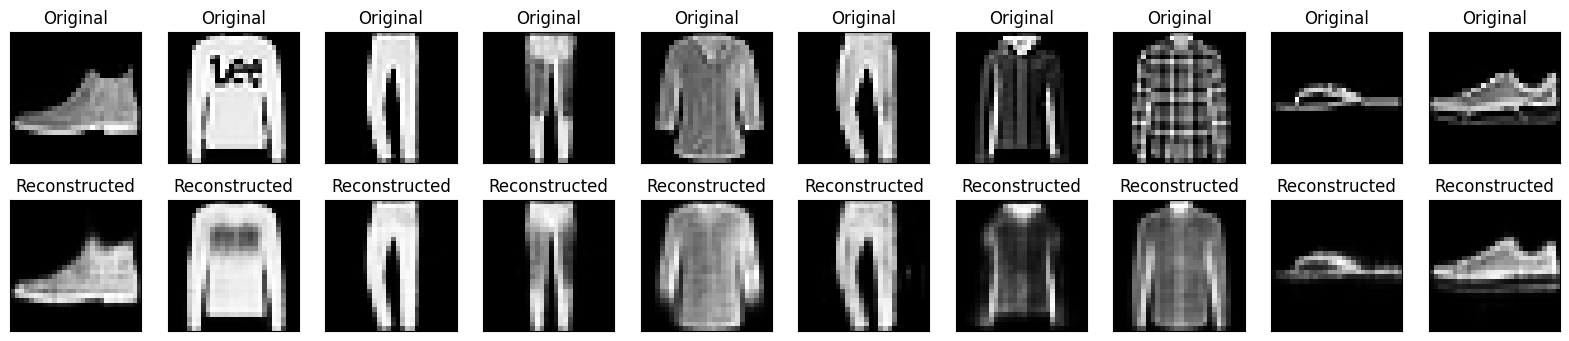

In [16]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    data_iter = iter(test_loader)
    images, _ = next(data_iter)
    images = images.to(device)

    reconstructed_images, _ = model(images)

original_images_reshaped = images.cpu().view(-1, 28, 28)
reconstructed_images_reshaped = reconstructed_images.cpu().view(-1, 28, 28)

num_display = 10
plt.figure(figsize=(20, 4))
for i in range(num_display):
    ax = plt.subplot(2, num_display, i + 1)
    plt.imshow(original_images_reshaped[i].numpy(), cmap='gray')
    ax.set_title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, num_display, i + 1 + num_display)
    plt.imshow(reconstructed_images_reshaped[i].numpy(), cmap='gray')
    ax.set_title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()